In [148]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

In [149]:
class SynthesiticRegressionData(d2l.DataModule):
    'synthesic data for linear regression'
    def __init__(self,w,b,noise=0.1, num_train=1000,num_val=100,batch_size=32):
        super().__init__()
        self.save_hyperparameters()
        n=num_train+num_val
        self.X=torch.randn(n,len(w))
        noise=torch.randn(n,1)*noise
        self.y=torch.matmul(self.X,w.reshape((-1,1)))+b+noise

@d2l.add_to_class(SynthesiticRegressionData)
def get_dataloader(self,train):
    if train:
        indices=list(range(self.num_train))
        random.shuffle(indices)
    else:
        indices=list(range(self.num_train,self.num_train+self.num_val))
    for i in range(0,len(indices),self.batch_size):
        batch_indices=torch.tensor(indices[i:i+self.batch_size])
        yield self.X[batch_indices],self.y[batch_indices]
data=SynthesiticRegressionData(w=torch.tensor([2,-3.4]),b=4.2)
X, y = next(iter(data.train_dataloader()))
print('X shape:', X.shape, '\ny shape:', y.shape)

#还是要多看源码我觉得应该需要多看源码
#concise implementation of the data loader


X shape: torch.Size([32, 2]) 
y shape: torch.Size([32, 1])


In [150]:
@d2l.add_to_class(d2l.DataModule)
def get_tensorloader(self,tensors,train,indices=slice((0,None))):
    tensors=tuple(a[indices] for a in tensors)
    dataset=torch.utils.data.TensorDataset(*tensors)
    return torch.utils.data.DataLoader(dataset,self.batch_size,shuffle=True)

@d2l.add_to_class(SynthesiticRegressionData)
def get_dataloader(self,train):
    i=slice(0,self.num_train) if train else slice(self.num_train, None)
    return self.get_tensorloader((self.X,self.y),train,i)
X,y=next(iter(data.train_dataloader()))
print(X,y)
    

tensor([[ 0.4680, -1.5881],
        [ 1.3780, -1.2171],
        [-0.7641,  1.4521],
        [ 0.9603, -0.0444],
        [ 0.9505,  1.8191],
        [ 0.3729,  0.2915],
        [ 1.5115,  1.5654],
        [-0.3548,  0.1065],
        [ 0.4241, -1.2878],
        [-1.9717,  0.2803],
        [-0.0110, -1.7484],
        [ 1.0756, -0.3032],
        [ 1.0775, -1.4429],
        [-1.1419,  0.7316],
        [ 0.2139,  0.6016],
        [ 0.9063,  0.5788],
        [ 0.4874,  2.3763],
        [ 0.2089, -1.3446],
        [-0.0454, -0.0844],
        [-0.1096, -0.6069],
        [ 0.2936,  1.0733],
        [ 1.3723, -0.1997],
        [-1.0248,  0.4157],
        [-0.2615,  1.4931],
        [ 0.3854, -1.9106],
        [ 0.1212,  0.8428],
        [-1.6216, -0.1894],
        [ 0.1655, -0.7925],
        [-0.1939,  0.6676],
        [ 0.5690,  0.9617],
        [ 0.7321, -0.9127],
        [ 0.1912, -0.4857]]) tensor([[10.5627],
        [11.1135],
        [-2.3208],
        [ 6.2963],
        [-0.1546],
        

## below is the linear regression implementatil=on from scratch


In [151]:
%matplotlib inline
import torch 
from d2l import torch as d2l
class LinearRegressionScratch(d2l.Module):
    """Linear Regression from scratch"""
    def __init__(self,num_inputs,lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.w=torch.normal(100,sigma,(num_inputs,1),requires_grad=True) #here the num_inputs is the number of the features
        self.b=torch.zeros(1, requires_grad=True)
@d2l.add_to_class(LinearRegressionScratch)
def forward(self,X):
    return torch.matmul(X,self.w)+self.b
@d2l.add_to_class(LinearRegressionScratch)
def loss(self,y_hat,y):
    l=(y_hat-y)**2/2
    return l.mean()

#define the optimization algorithm
class SGD(d2l.HyperParameters):
    def __init__(self,params,lr) -> None:
       self.save_hyperparameters()
    def step(self):
        with torch.no_grad():
            for param in self.params:
                param-=self.lr*param.grad
    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()
@d2l.add_to_class(LinearRegressionScratch)
def configure_optimizers(self):
    return SGD([self.w,self.b],self.lr)

@d2l.add_to_class(d2l.Trainer)
def prepare_batch(self,batch):
    return batch

@d2l.add_to_class(d2l.Trainer)
def fit_epoch(self):
    self.model.train()
    for batch in self.train_dataloader:
        loss = self.model.training_step(self.prepare_batch(batch))
        self.optim.zero_grad()
        loss.backward()  # 确保在 no_grad 之外
        if self.gradient_clip_val > 0:
            self.clip_gradients(self.gradient_clip_val, self.model)
        self.optim.step()
        # 【关键修改】移动到循环内部：每个 batch 记录一次
        self.train_batch_idx += 1 

    if self.val_dataloader is None:
        return
    self.model.eval()
    for batch in self.val_dataloader:
        with torch.no_grad():
            self.model.validation_step(self.prepare_batch(batch))
        # 【关键修改】移动到循环内部
        self.val_batch_idx += 1


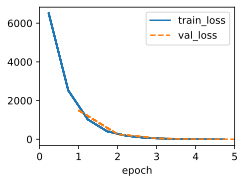

In [152]:
model = LinearRegressionScratch(2, lr=0.03)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=5)
trainer.fit(model, data)

In [153]:
with torch.no_grad():
    print(f'error in estimating w: {data.w - model.w.reshape(data.w.shape)}')
    print(f'error in estimating b: {data.b - model.b}')

error in estimating w: tensor([-1.1689, -1.1120])
error in estimating b: tensor([-0.2619])


In [154]:
class ExperimentalData(d2l.DataModule):
    def __init__(self,w,b,noise=0.01,num_train=1000,num_test=100,batch_size=32) -> None:
        super().__init__()
        self.save_hyperparameters()
        n=num_test+num_train
        self.X=torch.randn(n,len(w))
        noise=torch.randn(n,1)*noise
        self.y=torch.matmul(self.X,w.reshape(-1,1))+b+noise


        

In [155]:
@d2l.add_to_class(ExperimentalData)
def get_dataloader(self,train):
    if train:
        indices=list(range(0,self.num_train))
        random.shuffle(indices)
    else:
        indices=list(range(self.num_train,self.num_train+self.num_test))
    for i in range(0,len(indices),self.batch_size):
        batch_indice=torch.tensor(indices[i:i+self.batch_size])
        yield self.X[batch_indice],self.y[batch_indice]


In [156]:
@d2l.add_to_class(d2l.DataModule)
def get_tensorloader(self,tensor,train,indices=slice(0,None)):
    tensors=tuple(tensor[indices] for a in tensor)
    dataset=torch.utils.data.TensorDataset(*tensor)
    return torch.utils.data.DataLoader(dataset,self.batch_size,shuffle=train)
@d2l.add_to_class(ExperimentalData)
def get_dataloader(self,train):
    i=slice(0,self.num_train) if train else slice(self.num_train,self.num_train+self.num_test)
    return self.get_tensorloader((self.X,self.y),train,i)


In [157]:
MM=ExperimentalData(w=torch.tensor([1.0,2.0]),b=torch.tensor([1.0]))

In [158]:
MM.get_dataloader(True)

In [159]:
next(iter(MM.X))

tensor([-0.5286,  0.2458])

In [160]:
#Here is the exercise about the data generating and data loader
class ExperlimentData(d2l.DataModule):
    def __init__(self,w,b,noise=0.01,num_train=1000,num_test=100,batch_size=32):
        super().__init__()
        self.save_hyperparameters()
        n=num_train+num_test
        self.X=torch.randn(n,len(w))
        noise=torch.randn(n,1)*noise
        self.y=torch.matmul(self.X,w.reshape(-1,1))+b+noise

In [161]:
@d2l.add_to_class(d2l.DataModule)
def get_tensorloader(self,tensor,train, indices=slice(0,None)):
    tensor=tuple(a[indices] for a in tensor)
    dataset=torch.utils.data.TensorDataset(*tensor)
    return torch.utils.data.DataLoader(dataset,self.batch_size,shuffle=train)
@d2l.add_to_class(ExperlimentData)
def get_dataloader(self,train):
    indices=slice(0,self.num_train) if train else slice(self.num_train,self.num_train+self.num_test)
    return self.get_tensorloader((self.X,self.y),train,indices)
    

In [162]:
#Linear Regression From Scratch
class LinearRegressionScratch(d2l.Module):
    def __init__(self,num_inputs,lr,sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.w=torch.normal(0,sigma,(num_inputs,1),requires_grad=True)
        self.b=torch.zeros(1,requires_grad=True)
@d2l.add_to_class(LinearRegressionScratch)
def forward(self,X):
    return torch.matmul(X,self.w)+self.b
@d2l.add_to_class(LinearRegressionScratch)
def loss(self,y_hat,y):
    l=(y-y_hat)**2/2
    return l.mean()
class SGD(d2l.HyperParameters):
    def __init__(self,params,lr):
        self.save_hyperparameters()
    def step(self):
        with torch.no_grad():
            for param in self.params:
                param-=self.lr*param.grad
    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()
@d2l.add_to_class(LinearRegressionScratch)
def configure_optimizers(self):
    return SGD((self.w,self.b),self.lr)
#Here is for the training
@d2l.add_to_class(d2l.Trainer)
def prepare(self,batch):
    return batch
def fit_epoch(self):
    self.model.train()
    for batch in self.train_dataloader():
        loss =self.model.training_step(self.prepare_batch(batch))
        self.optim.zero_grad()
    with torch.no_grad():
        loss.backward()
        #if self.gradient_clip_val>0:
            #self.clip_gradients(self.gradient_clip_val,self.model)
        self.optim.step()
    self.train_batch_idx += 1
    if self.val_dataloader() is None:
        return
    self.model.eval()
    for batch in self.val_dataloader():
        with torch.no_grad():
            self.model.validation_step(self.prepare_batch(batch))
        self.val_batch_idx += 1     



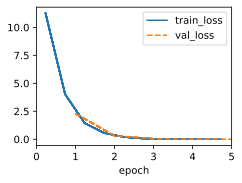

In [163]:
model = LinearRegressionScratch(2, lr=0.03)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=5)
trainer.fit(model, data)

In [164]:
model.w, model.b

(tensor([[ 1.9845],
         [-3.3844]], requires_grad=True),
 tensor([4.1694], requires_grad=True))

In [165]:
with torch.no_grad():
    print(f'error in estimating w: {data.w - model.w.reshape(data.w.shape)}')
    print(f'error in estimating b: {data.b - model.b}')

error in estimating w: tensor([ 0.0155, -0.0156])
error in estimating b: tensor([0.0306])


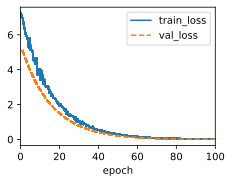

In [166]:
class LinearRegressionScratch(d2l.Module):
    def __init__(self,num_inputs,lr,sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.w=torch.randn((num_inputs,1),requires_grad=True)
        self.b=torch.zeros(1,requires_grad=True)
    def loss(self,y_hat,y):
        l=(y_hat-y)**2/2
        return l.mean()
    def forward(self,X):
        return torch.matmul(X,self.w.reshape(-1,1))+self.b
class SGD(d2l.HyperParameters):
    def __init__(self,params,lr):
        super().__init__()
        self.save_hyperparameters()
    def step(self):
        with torch.no_grad():
            for param in self.params:
                param-=self.lr*param.grad
    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

@d2l.add_to_class(LinearRegressionScratch)
def configure_optimizers(self):
    return SGD((self.w,self.b),self.lr)

@d2l.add_to_class(d2l.Trainer)
def prepare(self,batch):
    self.batch=batch
def fit_epoch(self):
    self.model.train()
    for batch in self.train_dataloader():
        loss=self.model.training_step(self.prepare_batch(batch))
    self.optim.zero_grad()
    with torch.no_grad():
        loss.backward()
        self.optim.step()
    self.train_batch_idx+=1
    if self.valid_dataloader==None:
        return
    self.model.eval()
    for batch in self.valid_dataloader():
        with torch.no_grad():
            self.model.validation_step(self.prepare_batch(batch))
        self.val_batch_idx += 1
MM=ExperlimentData(torch.tensor([1.0,2.0]),b=1.5)
model=LinearRegressionScratch(2,0.001)
trainer = d2l.Trainer(max_epochs=100)
trainer.fit(model, MM)

In [167]:
with torch.no_grad():
    print(model.w,model.b)

tensor([[1.0052],
        [1.8713]], requires_grad=True) tensor([1.4211], requires_grad=True)


In [168]:
#Here is for the practice
class TestData(d2l.DataModule):
    def __init__(self,w,b,noise=0.01,num_train=1000,num_valid=100,batch_size=32):
        super().__init__()
        self.save_hyperparameters()
        n=num_train+num_valid
        self.X=torch.randn((n,len(w)))
        self.y=torch.matmul(self.X,w.reshape(-1,1))+b+noise*torch.randn(n,1)
@d2l.add_to_class(d2l.DataModule)
def get_tensorloader(self,tensor,train,indices=slice(0,None)):
    tensor=tuple(a[indices] for a in tensor)
    dataset=torch.utils.data.TensorDataset(*tensor)
    return torch.utils.data.DataLoader(dataset,self.batch_size,shuffle=train)
@d2l.add_to_class(TestData)
def get_dataloader(self,train):
    indices=slice(0,self.num_train) if train else slice(self.num_train,self.num_train+self.num_valid)
    return self.get_tensorloader((self.X,self.y),train,indices)

In [169]:
class LinearRegression(d2l.Module):
    def __init__(self,num_features,lr):
        super().__init__()
        self.save_hyperparameters()
        self.w=torch.randn((num_features,1),requires_grad=True)
        self.b=torch.tensor([0.0],requires_grad=True)
    def forward(self,X):
        return torch.matmul(X,self.w)+self.b
    def loss(self,y_pred,y):
        l=(y_pred-y)**2/2
        return l.mean()
class SGD(d2l.HyperParameters):
    def __init__(self,params,lr):
        super().__init__()
        self.save_hyperparameters()
    def step(self):
        with torch.no_grad():
            for param in self.params:
                param-=param.grad*self.lr
    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()
@d2l.add_to_class(LinearRegression)
def configure_optimizers(self):
    return SGD((self.w,self.b),self.lr)
@d2l.add_to_class(d2l.Trainer)
def prepare(self,batch):
    self.batch=batch
@d2l.add_to_class(d2l.Trainer)
def fit_epoch(self):
    self.model.train()
    for batch in self.train_dataloader:
        loss=self.model.training_step(self.prepare_batch(batch))
        self.optim.zero_grad()
        with torch.no_grad():
            loss.backward()
            self.optim.step()
        self.train_batch_idx+=1
    if self.val_dataloader==None:
        return
    self.model.eval()
    for batch in self.val_dataloader:
        with torch.no_grad():
            loss=self.model.validation_step(self.prepare_batch(batch))
        self.val_batch_idx+=1


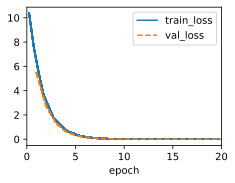

In [170]:
data=TestData(torch.tensor([-4.5,1.9]),torch.tensor(1.0))
model=LinearRegression(num_features=2,lr=0.01)
trainer=d2l.Trainer(max_epochs=20)
trainer.fit(model,data)

In [171]:
model.w,model.b

(tensor([[-4.4939],
         [ 1.9009]], requires_grad=True),
 tensor([0.9985], requires_grad=True))

In [173]:
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

In [174]:
class LinearRegressionApi(d2l.Module):
    def __init__(self, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net=nn.LazyLinear(1)
        self.net.weight.data.normal_(0,0.01)
        self.net.bias.data.fill_(0)